In [2]:
# importations 
import pandas as pd
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Config affichage
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.max_open_warning': 0})
import pandas as pd
pd.set_option('display.max_columns', None)

In [3]:
# Charger les fichiers de données
file_path1 = "players_stats_by_season_full_details.xlsx"
file_path2 = "NBA_Anthropometric.csv"

df1 = pd.read_excel(file_path1)
df2 = pd.read_csv(file_path2)

# Afficher les deux DataFrames
display(df1.head())
display(df2.head())

,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,3PA,FTM,FTA,TOV,PF,ORB,DRB,REB,AST,STL,BLK,PTS,birth_year,birth_month,birth_date,height,height_cm,weight,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team
0,NBA,1999 - 2000,Regular_Season,Shaquille O'Neal,LAL,79,3163.0,956,1665,0,1,432,824,223,255,336,742,1078,299,36,239,2344,1972.0,Mar,"Mar 6, 1972",2025-01-07 00:00:00,216.0,325.0,147.0,United States,Robert G. Cole High School,1.0,1.0,Orlando Magic
1,NBA,1999 - 2000,Regular_Season,Vince Carter,TOR,82,3126.0,788,1696,95,236,436,551,178,263,150,326,476,322,110,92,2107,1977.0,Jan,"Jan 26, 1977",2025-06-06 00:00:00,198.0,220.0,100.0,United States,Mainland High School,1.0,5.0,Golden State Warriors
2,NBA,1999 - 2000,Regular_Season,Karl Malone,UTA,82,2947.0,752,1476,2,8,589,739,231,229,169,610,779,304,79,71,2095,1963.0,Jul,"Jul 24, 1963",2025-09-06 00:00:00,206.0,265.0,120.0,United States,Summerfield High School,1.0,13.0,Utah Jazz
3,NBA,1999 - 2000,Regular_Season,Allen Iverson,PHI,70,2853.0,729,1733,89,261,442,620,230,162,71,196,267,328,144,5,1989,1975.0,Jun,"Jun 7, 1975",6-0,183.0,165.0,75.0,United States,Bethel High School,1.0,1.0,Philadelphia Sixers
4,NBA,1999 - 2000,Regular_Season,Gary Payton,SEA,82,3425.0,747,1666,177,520,311,423,224,178,100,429,529,732,153,18,1982,1968.0,Jul,"Jul 23, 1968",2025-04-06 00:00:00,193.0,180.0,82.0,United States,Skyline High School,1.0,2.0,Seattle SuperSonics


,player_name,position,height,height_with_shoes,weight,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,Trey Alexander,SG,191.14,NaN,83.73,208.28,257.81,NaN,21.59,22.22,2023
1,Amari Bailey,SG,191.14,NaN,86.55,200.66,262.89,NaN,20.32,23.50,2023
2,Emoni Bates,SF,203.84,NaN,81.28,205.74,266.70,NaN,20.32,20.96,2023
3,Reece Beekman,PG,186.69,NaN,86.45,200.66,255.27,NaN,21.59,20.96,2023
4,Anthony Black,PG,197.48,NaN,95.25,201.93,260.35,NaN,20.96,24.13,2023


In [4]:
# Pretreatment and feature engineering
#normalize names for merging
def normalize_name(s):
    if pd.isna(s):
        return s
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.replace('.', '').replace("'", '').replace('-', ' ')
    s = ' '.join(s.split())
    return s

# create normalized name columns
df1['player_norm'] = df1['Player'].apply(normalize_name)
df2['player_norm'] = df2['player_name'].apply(normalize_name)

# optional: reduce duplicates in df2 if there are multiple anthropometric rows per player
df2_unique = df2.drop_duplicates(subset=['player_norm']).copy()

# perform inner merge on normalized names (keeps only players present in both)
merged = pd.merge(df1, df2_unique, on='player_norm', how='inner', suffixes=('_stats','_anthro'))

# drop helper column if you don't want it
# merged = merged.drop(columns=['player_norm'])

# inspect results
print(f"Merged rows: {len(merged)}")
display(merged.head())

Merged rows: 6366


,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,3PA,FTM,FTA,TOV,PF,ORB,DRB,REB,AST,STL,BLK,PTS,birth_year,birth_month,birth_date,height_stats,height_cm,weight_stats,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team,player_norm,player_name,position,height_anthro,height_with_shoes,weight_anthro,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,NBA,1999 - 2000,Regular_Season,Glen Rice,LAL,80,2530.0,421,980,84,229,346,396,114,179,56,271,327,176,47,12,1272,1967.0,May,"May 28, 1967",2025-08-06 00:00:00,203.0,228.0,103.0,United States,Flint Northwestern High School,1.0,4.0,Miami Heat,glen rice,Glen Rice,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
1,NBA,1999 - 2000,Regular_Season,Jaren Jackson,SAS,81,1691.0,186,488,108,306,33,51,66,157,34,147,181,118,54,7,513,1967.0,Oct,"Oct 27, 1967",2025-04-06 00:00:00,193.0,190.0,86.0,United States,Walter Cohen High School,NaN,NaN,NaN,jaren jackson,Jaren Jackson,PF/C,207.64,211.46,107.05,226.70,279.40,7.20,25.40,25.40,2018
2,NBA,1999 - 2000,Playoffs,Glen Rice,LAL,23,766.0,93,228,28,67,71,89,36,50,10,82,92,48,15,4,285,1967.0,May,"May 28, 1967",2025-08-06 00:00:00,203.0,228.0,103.0,United States,Flint Northwestern High School,1.0,4.0,Miami Heat,glen rice,Glen Rice,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
3,Euroleague,2000 - 2001,International,Marko Jaric,BOL,22,631.3,79,180,17,55,53,76,58,62,17,50,67,50,43,5,228,1978.0,Oct,"Oct 12, 1978",2025-07-06 00:00:00,201.0,224.0,102.0,Serbia / Greece,NaN,2.0,1.0,Los Angeles Clippers,marko jaric,Marko Jaric,SG/SF,199.39,NaN,95.25,205.74,264.16,NaN,NaN,NaN,2000
4,Euroleague,2000 - 2001,International,Igor Rakocevic,BUD,11,327.9,50,120,10,45,32,49,16,30,9,21,30,20,15,0,142,1978.0,Mar,"Mar 29, 1978",2025-03-06 00:00:00,191.0,183.0,83.0,Serbia,NaN,2.0,22.0,Minnesota Timberwolves,igor rakocevic,Igor Rakocevic,PG,189.23,NaN,83.46,196.22,254.00,NaN,NaN,NaN,2000


In [5]:
#cleaning data, on supprime les colonnes height_stats, birth_month, birth_year and player_name, height_cm, wheight_kg
"""
We drop the following columns:
- height_stats: Redundant with height_anthro
- birth_month: Not needed for analysis
- birth_year: Not needed for analysis
- player_name: Redundant with Player   
- height_cm: Redundant with height_anthro
- wheight_kg: Redundant with weight_anthro
"""

cols_to_drop = ['height_stats', 'birth_month', 'birth_year', 'player_name', 'height_cm', 'weight_kg']

# drop from merged (safe: only drop columns that exist)
merged = merged.drop(columns=[c for c in cols_to_drop if c in merged.columns])

In [6]:
# convert the birth_date column to datetime format
# Convert birth_date like "Jan 26, 2002" -> "26.01.2002"
# verify the column exists
if 'birth_date' in merged.columns:

    # Parse the common textual dates
    # Exemple : "Jan 26, 2002"
    merged['birth_date_parsed'] = pd.to_datetime(
        merged['birth_date'], 
        errors='coerce', 
        infer_datetime_format=True
    )

    # Fallback for the english suffix (1st, 2nd, 3rd, 4th, ...)
    mask = merged['birth_date_parsed'].isna() & merged['birth_date'].notna()
    if mask.any():
        tmp = (
            merged.loc[mask, 'birth_date']
            .astype(str)
            .str.lower()
            .str.replace(r'(\d)(st|nd|rd|th)', r'\1', regex=True)
        )
        merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(
            tmp, 
            errors='coerce', 
            infer_datetime_format=True
        )
    
    # format the final column to "dd.mm.yyyy" (NaT → remains NaN)
    merged['birth_date'] = merged['birth_date_parsed'].dt.strftime('%d.%m.%Y')

    # delete the helper column
    merged = merged.drop(columns=['birth_date_parsed'])

else:
    print("Column 'birth_date' not found in merged.")

merged['birth_date'] = pd.to_datetime(merged['birth_date'], format='%d.%m.%Y', errors='coerce')

C:\Users\alves\AppData\Local\Temp\ipykernel_11768\4089267676.py:8: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged['birth_date_parsed'] = pd.to_datetime(
C:\Users\alves\AppData\Local\Temp\ipykernel_11768\4089267676.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(
C:\Users\alves\AppData\Local\Temp\ipykernel_11768\4089267676.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please

In [7]:
#calculate age at season start

def calcul_age_debut_saison(merged):
    """
    Calcuate the player's age at the start of the season (October 1 of the starting year),
    by extracting the first 4 digits from the 'Season' column.
    """
    # Extract the starting year from the 'Season' column
    merged['start_year'] = (
        merged['Season']
        .astype(str)
        .str[:4]
        .str.extract(r'(\d{4})')  # keep only 4 digit numbers
        .astype(float)
        .astype('Int64')
    )

    # Create a date for October 1 of the starting year
    merged['season_start_date'] = pd.to_datetime(
        merged['start_year'].astype(str) + '-10-01',
        errors='coerce'
    )

    # Calculate age at season start
    merged['age_debut_saison'] = ((merged['season_start_date'] - merged['birth_date']).dt.days / 365.25).round(1)

    return merged

# Application
merged = calcul_age_debut_saison(merged)

In [8]:
# extraire minutes jouées
minutes = merged['MIN']
print('temps minimum joué par un joueur',minutes.min())
print('temps maximum joué par un joueur',minutes.max())

temps minimum joué par un joueur 0.8
temps maximum joué par un joueur 3388.0


In [9]:
#créattion d'une colonne keyfactors qui est unique pour chaque ligne de merged
merged['keyfactor'] = merged.index

# create per minute columns
statistiques = ['FGM','FGA','3PM','3PA','FTM','FTA','TOV','PF','ORB','DRB','REB','AST','STL','BLK','PTS']

# get minutes as float, avoid division by zero
minutes = merged['MIN'].replace(0, np.nan).astype(float)

# create minutes column, avoid division by zero
created = []
for s in statistiques:
    if s in merged.columns:
        merged[f'{s}_per_min'] = merged[s].astype(float) / minutes
        merged[f'{s}_per_min'] = merged[f'{s}_per_min'].round(2)
        created.append(f'{s}_per_min')

print("Colonnes créées :", created)

# create a column EFF_per_min (measurement of a player's effectiveness per minute played)
merged['EFF_per_min'] = (
    (merged['PTS_per_min'] + merged['REB_per_min'] + merged['AST_per_min'] + merged['STL_per_min'] + merged['BLK_per_min'])
    - ((merged['FGA_per_min'] - merged['FGM_per_min']) + (merged['FTA_per_min'] - merged['FTM_per_min']) + merged['TOV_per_min'])
).round(2)


Colonnes créées : ['FGM_per_min', 'FGA_per_min', '3PM_per_min', '3PA_per_min', 'FTM_per_min', 'FTA_per_min', 'TOV_per_min', 'PF_per_min', 'ORB_per_min', 'DRB_per_min', 'REB_per_min', 'AST_per_min', 'STL_per_min', 'BLK_per_min', 'PTS_per_min']


In [10]:
# garder uniquement les lignes où la league est NBA
merged_NBA = merged[merged['League'] == 'NBA']

print(f"Lignes restantes après filtrage : {len(merged)}")

Lignes restantes après filtrage : 6366


In [11]:
# create function to plot distribution of a numeric column per unique player

def plot_player_distribution(df, player_col, value_col, unit=None):
    """
    Trace histogram + boxplot for a numeric column (e.g., height, age, weight)
    counting each player only once.
    
    Arguments :
    - df : DataFrame
    - player_col : str, nom de la colonne joueur
    - value_col : str, nom de la colonne numérique à tracer
    - unit : str, unité à afficher (ex: 'cm', 'kg', 'years')
    """

    # Delete rows with NaN in player_col or value_col as well as duplicates
    merged = df.dropna(subset=[player_col, value_col])
    merged_unique = merged.drop_duplicates(subset=[player_col])
    values = merged_unique[value_col].dropna()

    # Calculs descriptifs
    count = values.notna().sum()
    mean = values.mean()
    median = values.median()
    std = values.std()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    seuil_bas = q1 - 1.5 * iqr
    seuil_haut = q3 + 1.5 * iqr
    outliers_sup = merged[(merged[value_col] > seuil_haut)].sort_values(by=value_col, ascending=True)
    outliers_inf = merged[(merged[value_col] < seuil_bas)].sort_values(by=value_col, ascending=False)

    # Graphiques
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios':[3, 1]})

    # Histogramme + KDE
    sns.histplot(values, kde=True, bins=30, color='steelblue', ax=axes[0])
    axes[0].axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.1f} {unit or ''}")
    axes[0].axvline(median, color='green', linestyle='-.', label=f"Median: {median:.1f} {unit or ''}")
    axes[0].set_title(f"Distribution of player {value_col} ({count} unique players)")
    axes[0].set_xlabel(f"{value_col} ({unit or ''})")
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=values, color='lightgray', ax=axes[1])
    axes[1].axvline(mean, color='red', linestyle='--')
    axes[1].set_xlabel(f"{value_col} ({unit or ''})")
    axes[1].set_title(f"Boxplot — mean: {mean:.1f} {unit or ''}, std: {std:.1f}, IQR: {iqr:.1f}")

    plt.tight_layout()
    plt.show()

    # Résumé numérique
    print(f"{value_col.upper()} — Count: {count}, Mean: {mean:.1f} {unit or ''}, Median: {median:.1f} {unit or ''}, Std: {std:.1f}, IQR: {iqr:.1f}")
    print('Outliers supérieurs:')
    print(outliers_sup[['keyfactor','Player', value_col, 'Season']])
    print('Outliers inférieurs:')
    print(outliers_inf[['keyfactor','Player', value_col, 'Season']])

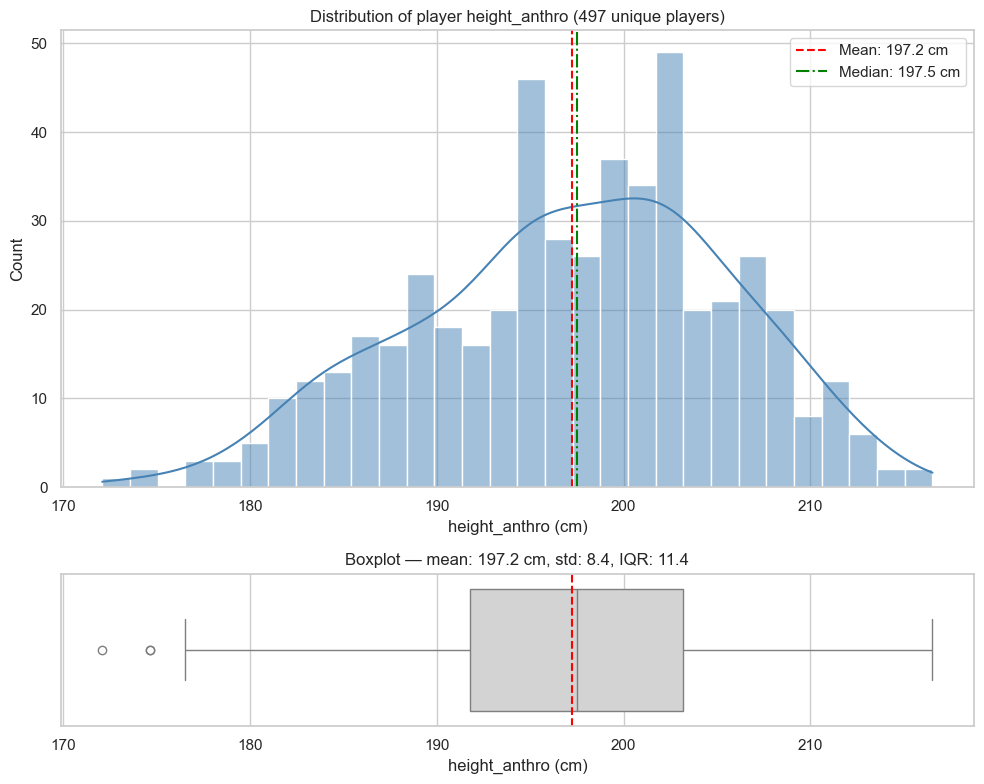

HEIGHT_ANTHRO — Count: 497, Mean: 197.2 cm, Median: 197.5 cm, Std: 8.4, IQR: 11.4
Outliers supérieurs:
Empty DataFrame
Columns: [keyfactor, Player, height_anthro, Season]
Index: []
Outliers inférieurs:
      keyfactor         Player  height_anthro       Season
3182       3182  Isaiah Thomas         174.62  2013 - 2014
3640       3640  Isaiah Thomas         174.62  2014 - 2015
2739       2739  Isaiah Thomas         174.62  2012 - 2013
2319       2319  Isaiah Thomas         174.62  2011 - 2012
4658       4658  Isaiah Thomas         174.62  2016 - 2017
5107       5107     Tyler Ulis         174.62  2017 - 2018
5680       5680     Tyler Ulis         174.62  2018 - 2019
4603       4603     Tyler Ulis         174.62  2016 - 2017
3811       3811  Isaiah Thomas         174.62  2014 - 2015
4454       4454  Isaiah Thomas         174.62  2016 - 2017
4206       4206  Isaiah Thomas         174.62  2015 - 2016
4045       4045  Isaiah Thomas         174.62  2015 - 2016
6159       6159  Isaiah Thomas 

In [12]:
# appel de la fonction pour la taille des joueurs
plot_player_distribution(merged_NBA, player_col='Player', value_col='height_anthro', unit='cm')

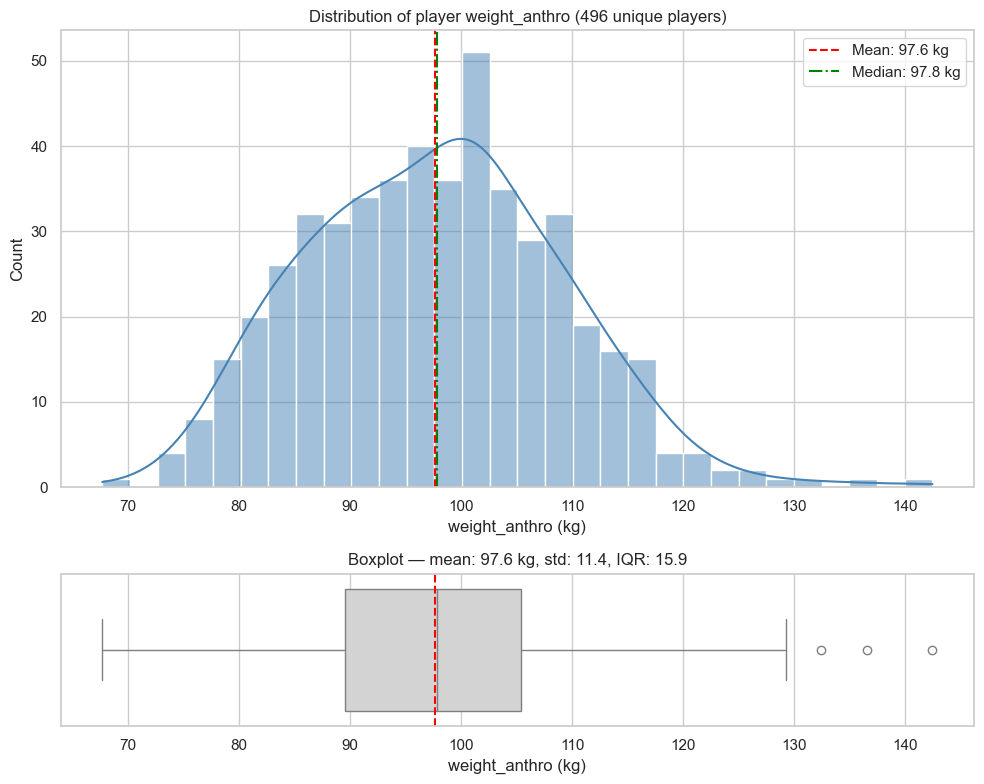

WEIGHT_ANTHRO — Count: 496, Mean: 97.6 kg, Median: 97.8 kg, Std: 11.4, IQR: 15.9
Outliers supérieurs:
      keyfactor            Player  weight_anthro       Season
1912       1912  DeMarcus Cousins         132.36  2010 - 2011
2279       2279  DeMarcus Cousins         132.36  2011 - 2012
2725       2725  DeMarcus Cousins         132.36  2012 - 2013
3175       3175  DeMarcus Cousins         132.36  2013 - 2014
5744       5744  DeMarcus Cousins         132.36  2018 - 2019
4460       4460  DeMarcus Cousins         132.36  2016 - 2017
4047       4047  DeMarcus Cousins         132.36  2015 - 2016
3620       3620  DeMarcus Cousins         132.36  2014 - 2015
708         708        Eddy Curry         136.53  2006 - 2007
63           63        Eddy Curry         136.53  2002 - 2003
157         157        Eddy Curry         136.53  2003 - 2004
479         479        Eddy Curry         136.53  2005 - 2006
25           25        Eddy Curry         136.53  2001 - 2002
561         561     DeSagana D

In [13]:
# appel de la fonction pour le poids des joueurs
plot_player_distribution(merged_NBA, player_col='Player', value_col='weight_anthro', unit='kg')

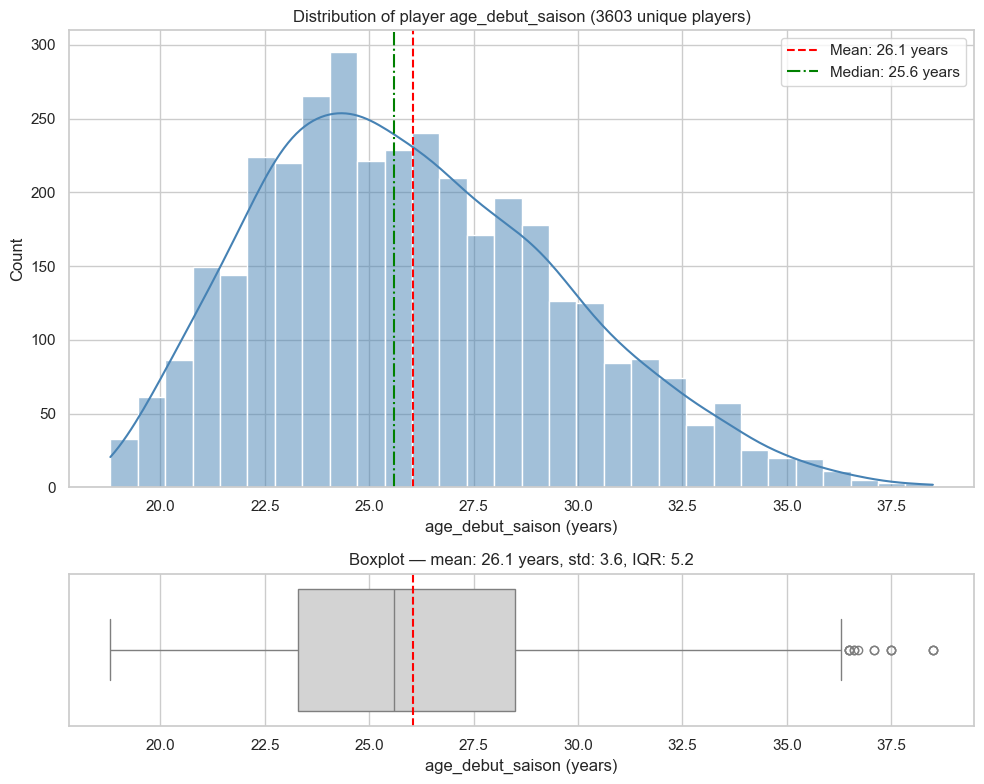

AGE_DEBUT_SAISON — Count: 3603, Mean: 26.1 years, Median: 25.6 years, Std: 3.6, IQR: 5.2
Outliers supérieurs:
      keyfactor          Player  age_debut_saison       Season
4508       4508  Jamal Crawford              36.5  2016 - 2017
4704       4704  Jamal Crawford              36.5  2016 - 2017
5181       5181     Kyle Korver              36.5  2017 - 2018
5078       5078     Kyle Korver              36.5  2017 - 2018
4762       4762     Matt Barnes              36.6  2016 - 2017
4588       4588     Matt Barnes              36.6  2016 - 2017
5533       5533     Dwyane Wade              36.7  2018 - 2019
5119       5119      David West              37.1  2017 - 2018
5233       5233      David West              37.1  2017 - 2018
5055       5055  Jamal Crawford              37.5  2017 - 2018
5235       5235  Jamal Crawford              37.5  2017 - 2018
5604       5604     Kyle Korver              37.5  2018 - 2019
5625       5625  Jamal Crawford              38.5  2018 - 2019
6192    

In [14]:
# appel de la fonction pour l'âge des joueurs début de saison
plot_player_distribution(merged_NBA, player_col='keyfactor', value_col='age_debut_saison', unit='years')

1.09
0.0
0.4758718190386428


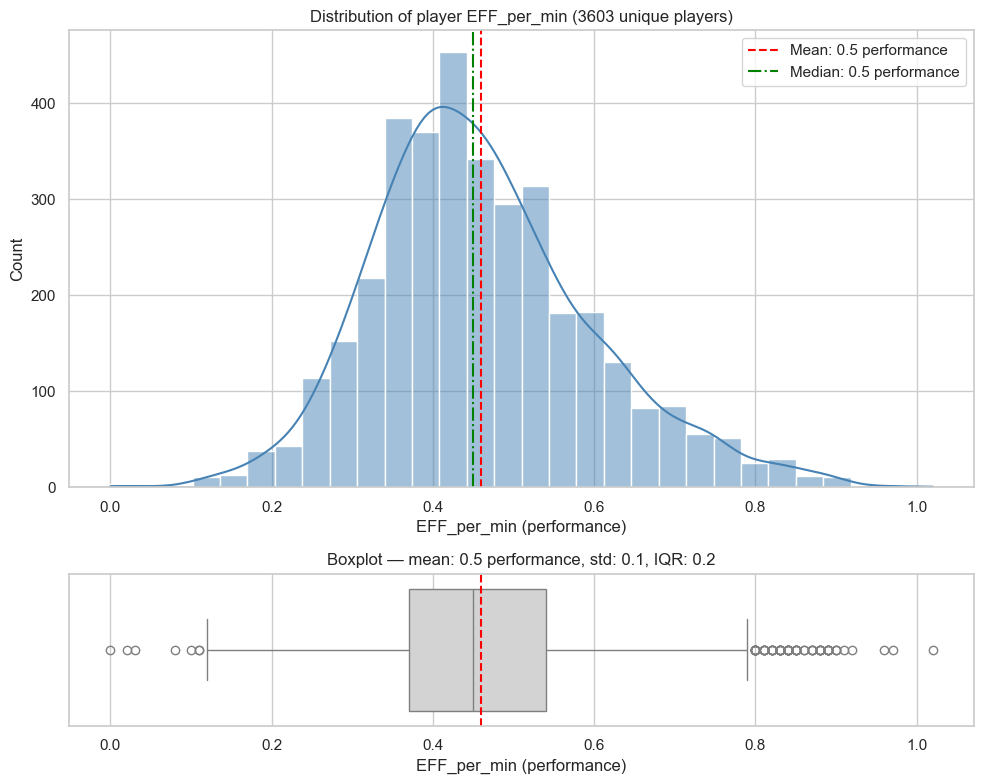

EFF_PER_MIN — Count: 3603, Mean: 0.5 performance, Median: 0.5 performance, Std: 0.1, IQR: 0.2
Outliers supérieurs:
      keyfactor             Player  EFF_per_min       Season
1255       1255       LeBron James         0.80  2008 - 2009
1895       1895         Kevin Love         0.80  2010 - 2011
2268       2268       LeBron James         0.80  2011 - 2012
3175       3175   DeMarcus Cousins         0.80  2013 - 2014
3606       3606      Stephen Curry         0.80  2014 - 2015
...         ...                ...          ...          ...
4671       4671  Russell Westbrook         0.91  2016 - 2017
4700       4700       JaVale McGee         0.92  2016 - 2017
6229       6229       LeBron James         0.96  2019 - 2020
4452       4452  Russell Westbrook         0.97  2016 - 2017
5509       5509      Anthony Davis         1.02  2018 - 2019

[76 rows x 4 columns]
Outliers inférieurs:
      keyfactor          Player  EFF_per_min       Season
2493       2493   Jason Collins         0.11  2011 

In [15]:
# infos on EFF_per_min 
print(merged['EFF_per_min'].max())
print(merged['EFF_per_min'].min())
print(merged['EFF_per_min'].mean())
plot_player_distribution(merged_NBA, player_col='keyfactor', value_col='EFF_per_min', unit='performance')

In [16]:
# creation of a linear regression function with statsmodels
def regression_lineaire(df, cible, variables):
    """
    Effectue une régression linéaire avec statsmodels.

    Paramètres
    ----------
    df : pd.DataFrame
        Ton DataFrame complet.
    cible : str
        Nom de la variable dépendante (y).
    variables : list
        Liste des variables explicatives (X).
    
    Retour
    ------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Le modèle ajusté.
    """
    # Vérifie la présence des colonnes
    colonnes = [cible] + variables
    data = df[colonnes].dropna()
    
    # Définition des variables
    X = data[variables]
    y = data[cible]
    
    # Ajout de la constante
    X = sm.add_constant(X)
    
    # Modèle
    model = sm.OLS(y, X).fit()
    
    # Affichage synthétique
    print("📊 RÉGRESSION LINÉAIRE")
    print(f"Variable dépendante : {cible}")
    print(f"Variables explicatives : {', '.join(variables)}\n")
    print(model.summary())
    
    return model

In [17]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['height_anthro'])

📊 RÉGRESSION LINÉAIRE
Variable dépendante : EFF_per_min
Variables explicatives : height_anthro

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     211.0
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.70e-46
Time:                        09:55:06   Log-Likelihood:                 2132.4
No. Observations:                3588   AIC:                            -4261.
Df Residuals:                    3586   BIC:                            -4248.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [18]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['wingspan'])

📊 RÉGRESSION LINÉAIRE
Variable dépendante : EFF_per_min
Variables explicatives : wingspan

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     353.2
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           3.07e-75
Time:                        09:55:06   Log-Likelihood:                 2200.5
No. Observations:                3593   AIC:                            -4397.
Df Residuals:                    3591   BIC:                            -4385.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [19]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['weight_anthro'])


📊 RÉGRESSION LINÉAIRE
Variable dépendante : EFF_per_min
Variables explicatives : weight_anthro

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     245.4
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.47e-53
Time:                        09:55:07   Log-Likelihood:                 2146.8
No. Observations:                3586   AIC:                            -4290.
Df Residuals:                    3584   BIC:                            -4277.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [20]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['age_debut_saison'])


📊 RÉGRESSION LINÉAIRE
Variable dépendante : EFF_per_min
Variables explicatives : age_debut_saison

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.03160
Date:                Tue, 16 Dec 2025   Prob (F-statistic):              0.859
Time:                        09:55:07   Log-Likelihood:                 2038.2
No. Observations:                3603   AIC:                            -4072.
Df Residuals:                    3601   BIC:                            -4060.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [21]:
# Filtrage pour un modèle en Saison Régulière ou Playoffs
merged_NBA_regular = merged_NBA[merged_NBA['Stage'] == 'Regular_Season'].copy()
merged_NBA_playoffs = merged_NBA[merged_NBA['Stage'] == 'Playoffs'].copy()

# 1. Simplification initiale (prendre ce qu'il y a avant le slash)
merged_NBA_regular['Simplified_Position'] = merged_NBA_regular['position'].str.split('/').str[0].fillna('Unknown')

# 2. Normalisation des noms (PG, SG, etc.)
valid_positions = ['PG', 'SG', 'SF', 'PF', 'C']
merged_NBA_regular['Simplified_Position'] = merged_NBA_regular['Simplified_Position'].apply(
    lambda x: x.upper() if x.upper() in valid_positions else x
)

# 3. Nettoyage final des variables du modèle
model_vars = ['EFF_per_min', 'height_anthro', 'weight_anthro', 'age_debut_saison', 'Simplified_Position']
merged_NBA_regular.dropna(subset=model_vars, inplace=True)

# 4. Retirer la catégorie 'Unknown'
merged_NBA_regular = merged_NBA_regular[merged_NBA_regular['Simplified_Position'] != 'Unknown'].copy()

# 5 sauvegarder le dataset filtré
merged_NBA_regular.to_csv('merged_NBA_regular.csv', index=False)
merged_NBA_playoffs.to_csv('merged_NBA_playoffs.csv', index=False)

In [22]:

# Définition et exécution du modèle de régression (avec modération: Taille * Âge)
formula = 'EFF_per_min ~ height_anthro + weight_anthro + age_debut_saison + height_anthro:age_debut_saison'
model = smf.ols(formula=formula, data=merged_NBA_regular).fit()

# 5. Affichage du résumé
print("--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil) ---")
print("Modèle: EFF_per_min = B0 + B1*Taille + B2*Poids + B3*Âge + B4*(Taille * Âge)")
print(model.summary())

--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil) ---
Modèle: EFF_per_min = B0 + B1*Taille + B2*Poids + B3*Âge + B4*(Taille * Âge)
                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     54.16
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.23e-43
Time:                        09:55:07   Log-Likelihood:                 1525.2
No. Observations:                2251   AIC:                            -3040.
Df Residuals:                    2246   BIC:                            -3012.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err     

In [23]:
# Définition et exécution du modèle de régression (avec modération et Position)
formula = 'EFF_per_min ~ height_anthro + weight_anthro + age_debut_saison + height_anthro:age_debut_saison + C(Simplified_Position)'
model = smf.ols(formula=formula, data=merged_NBA_regular).fit()

# 5. Affichage du résumé
print("--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil + Position) ---")
print("Modèle: EFF_per_min = f(Taille, Poids, Âge, Taille * Âge, Position)")
print(model.summary())

--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil + Position) ---
Modèle: EFF_per_min = f(Taille, Poids, Âge, Taille * Âge, Position)
                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     53.48
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           9.37e-80
Time:                        09:55:07   Log-Likelihood:                 1618.1
No. Observations:                2251   AIC:                            -3218.
Df Residuals:                    2242   BIC:                            -3167.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err   

Bien que les facteurs physiques n'expliquent qu'une petite partie de la variance totale ($\mathbf{R^2}$ Ajusté $\mathbf{= 4.5\%}$), ils sont significatifs. La performance ($\text{EFF/min}$) est principalement déterminée par le Poids et la Position du joueur, l'expérience étant plus bénéfique pour l'efficacité des joueurs de petite taille.

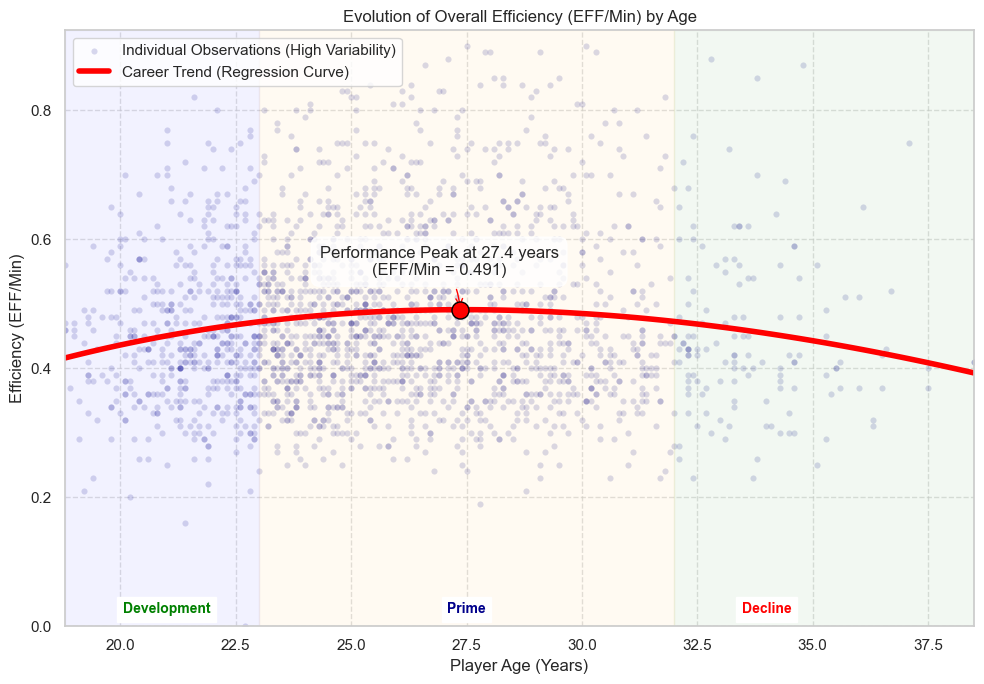

In [24]:
# Determine the age column
age_col = 'Age'
if 'age_debut_saison' in merged_NBA_regular.columns:
    age_col = 'age_debut_saison'

merged_NBA_regular[age_col] = pd.to_numeric(
    merged_NBA_regular[age_col],
    errors='coerce'
)


# --- 1. Filtering multi-season players and data cleaning ---
player_season_counts = merged_NBA_regular.groupby('Player')['Season'].nunique()
multi_season_players = player_season_counts[player_season_counts > 1].index

df_analysis = merged_NBA_regular[
    merged_NBA_regular['Player'].isin(multi_season_players)
].copy()


# --- 2. Identifying the performance peak (polynomial regression) ---
coeffs = np.polyfit(df_analysis[age_col], df_analysis['EFF_per_min'], 3)
poly = np.poly1d(coeffs)

age_min = df_analysis[age_col].min()
age_max = df_analysis[age_col].max()
age_range = np.linspace(age_min, age_max, 100)
predicted_eff = poly(age_range)

peak_index = np.argmax(predicted_eff)
peak_age = age_range[peak_index]
peak_eff = predicted_eff[peak_index]
peak_age_rounded = round(peak_age, 1)


# --- 3. Combined visualization (scatter + trend + annotations) ---
plt.figure(figsize=(10, 7))

# A. Scatter plot of all observations (shows high variability)
sns.scatterplot(
    data=df_analysis,
    x=age_col,
    y='EFF_per_min',
    alpha=0.15,
    color='darkblue',
    s=20,
    label='Individual Observations (High Variability)'
)

# B. Polynomial trend curve (shows career evolution)
plt.plot(
    age_range,
    predicted_eff,
    color='red',
    linestyle='-',
    linewidth=4,
    label='Career Trend (Regression Curve)'
)

# C. Performance peak annotation
plt.scatter(
    peak_age,
    peak_eff,
    color='red',
    s=150,
    zorder=5,
    edgecolor='black'
)
plt.annotate(
    f"Performance Peak at {peak_age_rounded} years\n(EFF/Min = {peak_eff:.3f})",
    (peak_age, peak_eff),
    textcoords="offset points",
    xytext=(-15, 25),
    ha='center',
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.2",
        color='red'
    ),
    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8)
)

# D. Determine a low Y position for labels
y_pos_low = df_analysis['EFF_per_min'].min() + 0.02

# E. Career phase annotations (bottom of the plot)
plt.axvspan(age_min, 23, color='blue', alpha=0.05)
plt.text(
    21, y_pos_low, 'Development',
    color='green', ha='center', fontsize=10,
    weight='bold', backgroundcolor='white'
)

plt.axvspan(32, age_max, color='green', alpha=0.05)
plt.text(
    34, y_pos_low, 'Decline',
    color='red', ha='center', fontsize=10,
    weight='bold', backgroundcolor='white'
)

plt.axvspan(23, 32, color='orange', alpha=0.05)
plt.text(
    27.5, y_pos_low, 'Prime',
    color='darkblue', ha='center', fontsize=10,
    weight='bold', backgroundcolor='white'
)


plt.title("Evolution of Overall Efficiency (EFF/Min) by Age")
plt.xlabel("Player Age (Years)")
plt.ylabel("Efficiency (EFF/Min)")
plt.xlim(age_min, age_max)
plt.ylim(
    df_analysis['EFF_per_min'].min() * 0.95,
    df_analysis['EFF_per_min'].quantile(0.99) * 1.1
)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the figure
plt.savefig('efficiency_evolution_by_age.png', dpi=300, bbox_inches="tight")

# --- COMMAND TO DISPLAY THE PLOT INTERACTIVELY IN YOUR ENVIRONMENT ---
plt.show()

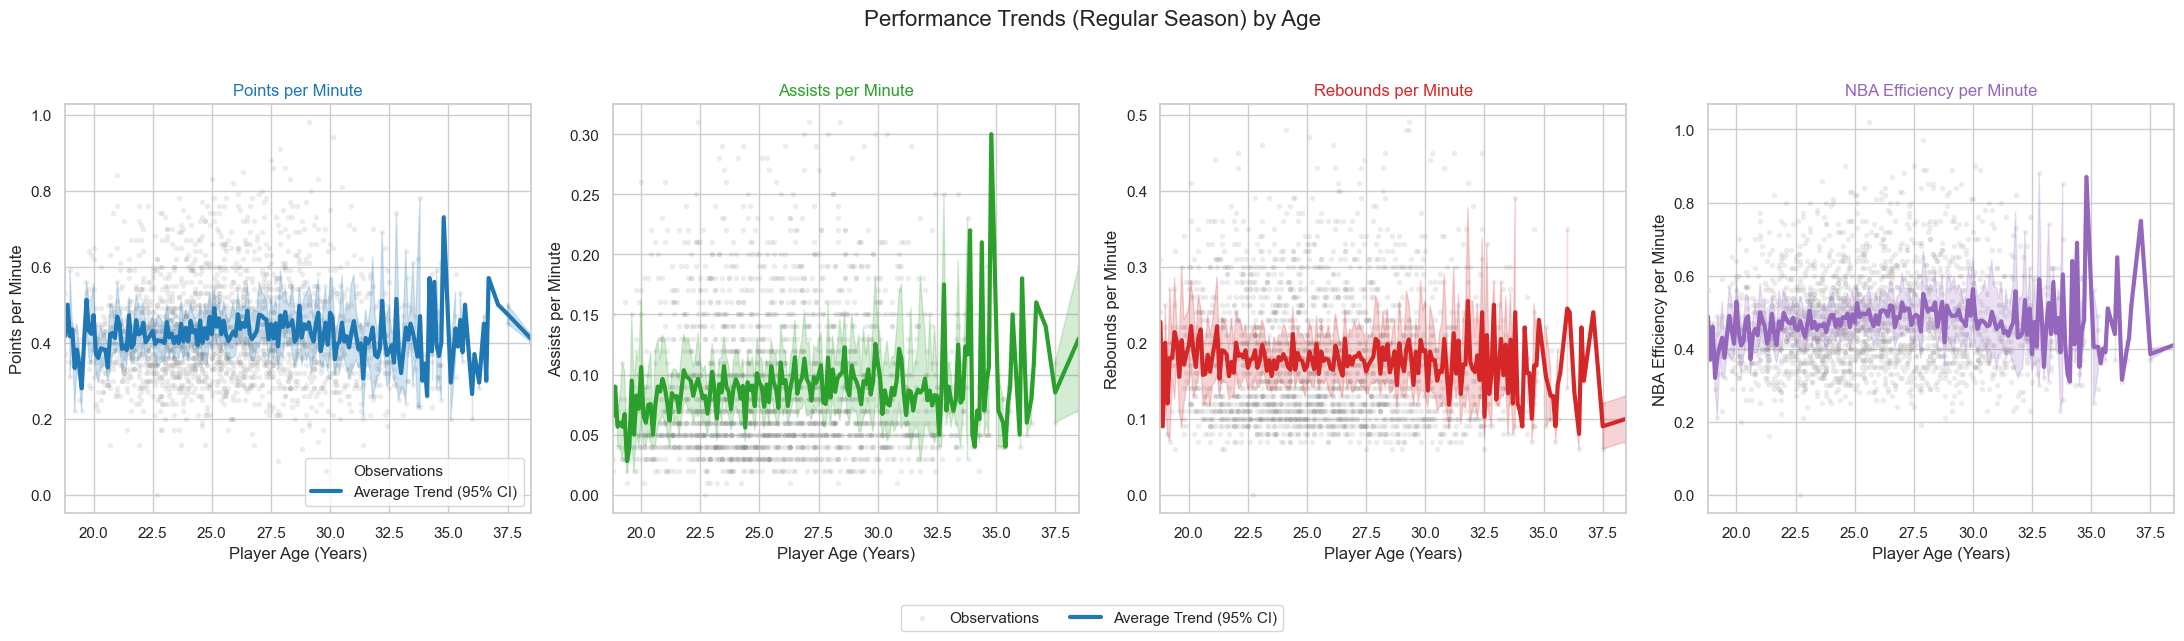

In [25]:
# --- 3. Visualization: Evolution of the 4 performance metrics by Age ---
metrics_to_plot = {
    'PTS_per_min': 'Points per Minute',
    'AST_per_min': 'Assists per Minute',
    'REB_per_min': 'Rebounds per Minute',
    'EFF_per_min': 'NBA Efficiency per Minute'  # Requested metric
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharex=True)
fig.suptitle("Performance Trends (Regular Season) by Age", fontsize=16)

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']  # Blue, Green, Red, Purple

for i, (metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    color = colors[i]

    df_plot = df_analysis.dropna(subset=[metric])

    # 1. Scatter plot of all observations (shows variability)
    sns.scatterplot(
        data=df_plot,
        x=age_col,
        y=metric,
        alpha=0.15,
        color='gray',
        s=15,
        ax=ax,
        label='Observations' if i == 0 else ""
    )

    # 2. Mean trend line with confidence interval
    sns.lineplot(
        data=df_plot,
        x=age_col,
        y=metric,
        estimator='mean',
        errorbar=('ci', 95),  # 95% confidence interval
        color=color,
        linewidth=3,
        label='Average Trend (95% CI)' if i == 0 else "",
        ax=ax
    )

    ax.set_title(title, fontsize=12, color=color)
    ax.set_xlabel('Player Age (Years)')
    ax.set_ylabel(title)
    ax.set_xlim(df_plot[age_col].min(), df_plot[age_col].max())


# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the figure
plt.savefig('performance_evolution_by_age.png', dpi=300, bbox_inches="tight")

# --- COMMAND TO DISPLAY THE PLOT INTERACTIVELY ---
plt.show()

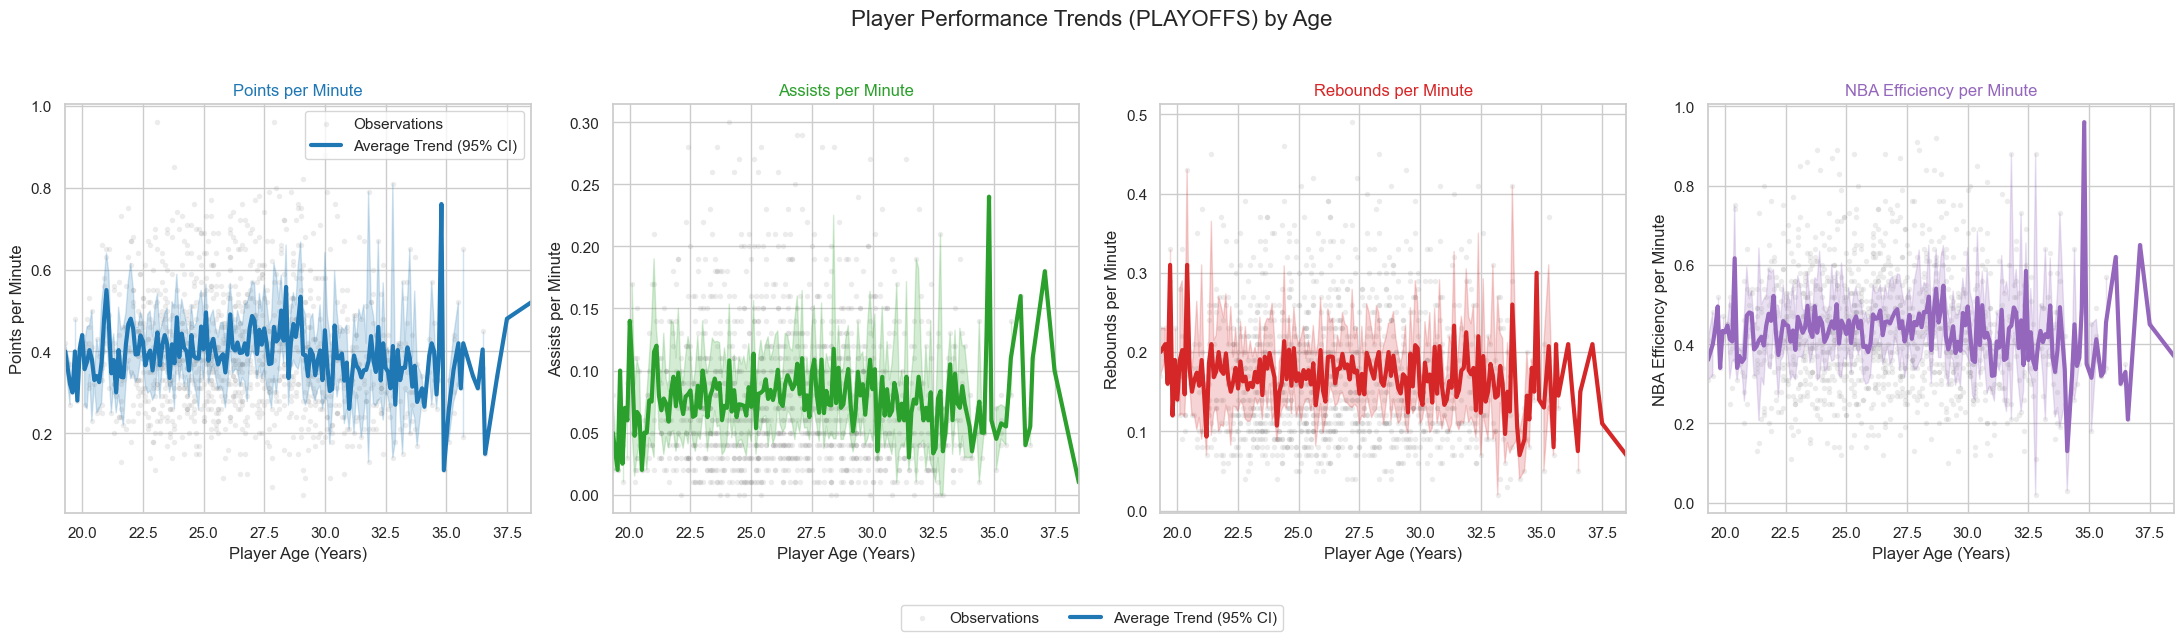

In [26]:
# --- 1. Filtering multi-season players and data cleaning ---
player_season_counts = merged_NBA_playoffs.groupby('Player')['Season'].nunique()
multi_season_players = player_season_counts[player_season_counts > 1].index

df_analysis_playoffs = merged_NBA_playoffs[
    merged_NBA_playoffs['Player'].isin(multi_season_players)
].copy()

# --- 2. Visualization: Evolution of the 4 performance metrics by Age (PLAYOFFS) ---
metrics_to_plot = {
    'PTS_per_min': 'Points per Minute',
    'AST_per_min': 'Assists per Minute',
    'REB_per_min': 'Rebounds per Minute',
    'EFF_per_min': 'NBA Efficiency per Minute'
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharex=True)
fig.suptitle("Player Performance Trends (PLAYOFFS) by Age", fontsize=16)

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']

for i, (metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    color = colors[i]

    df_plot = df_analysis_playoffs.dropna(subset=[metric])

    # 1. Scatter plot of all observations (shows variability)
    sns.scatterplot(
        data=df_plot,
        x=age_col,
        y=metric,
        alpha=0.15,
        color='gray',
        s=15,
        ax=ax,
        label='Observations' if i == 0 else ""
    )

    # 2. Mean trend line with confidence interval
    # Note: Using a trend line approach to capture career trajectories
    sns.lineplot(
        data=df_plot,
        x=age_col,
        y=metric,
        estimator='mean',
        errorbar=('ci', 95),  # 95% confidence interval
        color=color,
        linewidth=3,
        label='Average Trend (95% CI)' if i == 0 else "",
        ax=ax
    )

    ax.set_title(title, fontsize=12, color=color)
    ax.set_xlabel('Player Age (Years)')
    ax.set_ylabel(title)
    ax.set_xlim(df_plot[age_col].min(), df_plot[age_col].max())


# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the figure
plt.savefig('performance_evolution_by_age_playoffs.png', dpi=300, bbox_inches="tight")

# --- COMMAND TO DISPLAY THE PLOT INTERACTIVELY ---
plt.show()

In [27]:
# --- 1. Filtrage des joueurs multi-saisons et nettoyage ---
player_season_counts = merged_NBA.groupby('Player')['Season'].nunique()
multi_season_players = player_season_counts[player_season_counts > 1].index

df_analysis = merged_NBA[merged_NBA['Player'].isin(multi_season_players)].copy()
df_analysis = df_analysis[df_analysis['MIN'] >= 100].copy() # Filtrage MIN >= 100

# Création de colonnes supplémentaires pour les tests
df_analysis['FGA_minus_FGM_per_min'] = (df_analysis['FGA_per_min'] - df_analysis['FGM_per_min'])
df_analysis['FTA_minus_FTM_per_min'] = (df_analysis['FTA_per_min'] - df_analysis['FTM_per_min'])

# --- 2. Test t de Student pour TOUTES les métriques ---
print("\n--- Synthèse du Test t (TOUTES les Statistiques : Playoffs vs. Saison Régulière) ---")

metrics_to_test = {
    'PTS_per_min': 'Points/min (Offense)',
    'AST_per_min': 'Assists/min (Offense)',
    'REB_per_min': 'Rebounds/min (Offense)',
    'EFF_per_min': 'EFF/min (Overall)',
    'STL_per_min': 'Steals/min (Defense)',
    'BLK_per_min': 'Blocks/min (Defense)',
    'TOV_per_min': 'Turnovers/min (Negative)',
    'FGA_minus_FGM_per_min': 'Missed FGs/min (Negative)',
    'FTA_minus_FTM_per_min': 'Missed FTs/min (Negative)'
}

results = {}
for metric, label in metrics_to_test.items():
    reg_season_data = df_analysis[df_analysis['Stage'] == 'Regular_Season'][metric].dropna()
    playoffs_data = df_analysis[df_analysis['Stage'] == 'Playoffs'][metric].dropna()

    if len(reg_season_data) > 1 and len(playoffs_data) > 1:
        t_stat, p_value = stats.ttest_ind(reg_season_data, playoffs_data, equal_var=False)
        results[label] = {
            'Moyenne Rég.': reg_season_data.mean(),
            'Moyenne Playoffs': playoffs_data.mean(),
            'Valeur p': p_value,
            'Statistique t': t_stat
        }

results_df = pd.DataFrame(results).T.round(4)
results_df['Significatif (p<0.05)'] = results_df['Valeur p'] < 0.05
print("Résultats des tests t de Student (Saison Régulière vs Playoffs) :")
print(results_df.sort_values(by='Valeur p'))



--- Synthèse du Test t (TOUTES les Statistiques : Playoffs vs. Saison Régulière) ---
Résultats des tests t de Student (Saison Régulière vs Playoffs) :
                           Moyenne Rég.  Moyenne Playoffs  Valeur p  \
Assists/min (Offense)            0.0886            0.0802    0.0000   
EFF/min (Overall)                0.4771            0.4454    0.0000   
Turnovers/min (Negative)         0.0556            0.0525    0.0005   
Points/min (Offense)             0.4252            0.4079    0.0006   
Steals/min (Defense)             0.0317            0.0299    0.0008   
Rebounds/min (Offense)           0.1773            0.1704    0.0177   
Missed FTs/min (Negative)        0.0238            0.0250    0.1325   
Blocks/min (Defense)             0.0201            0.0195    0.4234   
Missed FGs/min (Negative)        0.1864            0.1850    0.5542   

                           Statistique t  Significatif (p<0.05)  
Assists/min (Offense)             4.1011                   True  
EFF/m

Note méthodologique : Une valeur $p < 0.05$ indique que la différence entre les deux moyennes est statistiquement significative.
📊 Interprétation de la Différence StatistiqueLes résultats du Test t démontrent que la baisse d'efficacité (EFF/min) et de production pour la majorité des métriques offensives et défensives est statistiquement significative en Playoffs.Analyse causale :Cette tendance s'explique principalement par une intensité défensive et une rigueur stratégique accrues lors des séries éliminatoires. Cela entraîne :Une diminution du rythme de jeu (Pace).Une baisse du nombre de possessions par minute.Par conséquent, une réduction mécanique de la fréquence de tous les événements statistiques (réussites comme erreurs) par unité de temps.

In [28]:
# Filtrage pour l'analyse
df_robust = merged_NBA[merged_NBA['MIN'] >= 100].copy()


# --- 1. Calcul de l'EFF/min MOYENNE pour chaque joueur sur leur carrière Reg. Season ---
player_reg_season_mean = df_robust[df_robust['Stage'] == 'Regular_Season'].groupby('Player')['EFF_per_min'].mean().reset_index()
player_reg_season_mean.rename(columns={'EFF_per_min': 'Avg_EFF_Reg_Season'}, inplace=True)

# 2. Identifier les joueurs ÉLITES (Top 10% en EFF/Min Reg. Season)
# Calculer le seuil du 90e percentile
top_percentile = player_reg_season_mean['Avg_EFF_Reg_Season'].quantile(0.90)
elite_players = player_reg_season_mean[player_reg_season_mean['Avg_EFF_Reg_Season'] >= top_percentile]['Player']

print(f"Seuil du Top 10% d'efficacité (EFF/Min) en Saison Régulière : {top_percentile:.4f}")
print(f"Nombre de joueurs dans le groupe Élite : {len(elite_players)}")


# 3. Calculer le DIFFÉRENTIEL (Playoffs - Reg. Season) pour le groupe Élite
# Filtrer les performances de TOUS les joueurs (Reg. Season et Playoffs)
pivot_eff = df_robust.groupby(['Player', 'Stage'])['EFF_per_min'].mean().unstack().reset_index()
pivot_eff.rename(columns={'Regular_Season': 'Avg_EFF_Reg_Season_Full', 'Playoffs': 'Avg_EFF_Playoffs_Full'}, inplace=True)

# S'assurer que les joueurs ont joué dans les deux stages (Reg. Season et Playoffs)
pivot_eff.dropna(subset=['Avg_EFF_Reg_Season_Full', 'Avg_EFF_Playoffs_Full'], inplace=True)


# Filtrer le pivot UNIQUEMENT pour les joueurs élites identifiés à l'étape 2
elite_comparison = pivot_eff[pivot_eff['Player'].isin(elite_players)].copy()

# Calculer le différentiel
elite_comparison['EFF_DIFFERENTIAL'] = elite_comparison['Avg_EFF_Playoffs_Full'] - elite_comparison['Avg_EFF_Reg_Season_Full']

# 4. Afficher et Analyser les résultats
mean_elite_diff = elite_comparison['EFF_DIFFERENTIAL'].mean()
mean_elite_reg = elite_comparison['Avg_EFF_Reg_Season_Full'].mean()
mean_elite_po = elite_comparison['Avg_EFF_Playoffs_Full'].mean()

print("\n--- Analyse de l'Évolution des Joueurs Élites (Top 10% EFF/Min) ---")
print(f"Efficacité moyenne en Saison Régulière (Groupe Élite) : {mean_elite_reg:.4f}")
print(f"Efficacité moyenne en Playoffs (Groupe Élite) : {mean_elite_po:.4f}")
print(f"Différence Moyenne (Playoffs - Reg. Season) pour le Groupe Élite : {mean_elite_diff:.4f}")

if mean_elite_diff > 0:
    print("\nConclusion : Le groupe Élite montre une augmentation moyenne d'efficacité en Playoffs. Ils 'carrient' leur équipe.")
else:
    print("\nConclusion : Le groupe Élite montre une diminution moyenne d'efficacité en Playoffs, se conformant à la tendance générale, mais gère la pression mieux que la moyenne.")

# Afficher les 5 meilleurs différentiels au sein de ce groupe Élite
top_5_elite_specialists = elite_comparison.sort_values(by='EFF_DIFFERENTIAL', ascending=False).head(5)
print("\nTop 5 des joueurs Élite qui s'améliorent le plus en Playoffs:")
print(top_5_elite_specialists[['Player', 'Avg_EFF_Reg_Season_Full', 'Avg_EFF_Playoffs_Full', 'EFF_DIFFERENTIAL']].round(4))

Seuil du Top 10% d'efficacité (EFF/Min) en Saison Régulière : 0.6094
Nombre de joueurs dans le groupe Élite : 49

--- Analyse de l'Évolution des Joueurs Élites (Top 10% EFF/Min) ---
Efficacité moyenne en Saison Régulière (Groupe Élite) : 0.6843
Efficacité moyenne en Playoffs (Groupe Élite) : 0.6081
Différence Moyenne (Playoffs - Reg. Season) pour le Groupe Élite : -0.0762

Conclusion : Le groupe Élite montre une diminution moyenne d'efficacité en Playoffs, se conformant à la tendance générale, mais gère la pression mieux que la moyenne.

Top 5 des joueurs Élite qui s'améliorent le plus en Playoffs:
Stage         Player  Avg_EFF_Reg_Season_Full  Avg_EFF_Playoffs_Full  \
221    Jarrett Allen                   0.6600                 0.7400   
181      Greg Monroe                   0.6286                 0.6450   
279    Kawhi Leonard                   0.6662                 0.6725   
306     LeBron James                   0.7582                 0.7493   
200     JaVale McGee              

R² linéaire = 0.1487406672920284
R² polynomial (deg=2) = 0.21784262955873157


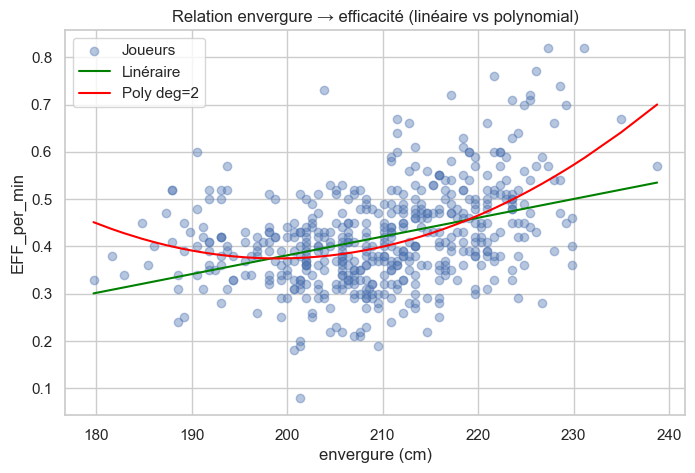

In [29]:
# Analyse de la relation entre envergure et EFF_per_min avec régression linéaire et polynomial
# Préparer les données
merged_NBA_height = merged_NBA[["wingspan", "EFF_per_min",'Player']].dropna()
merged_NBA_height = merged_NBA_height.drop_duplicates(subset=["Player"], keep="first")

#Préparer X (taille) et y (efficacité)
X = merged_NBA_height[["wingspan"]].values  # shape (n, 1)
y = merged_NBA_height["EFF_per_min"].values  # shape (n,)

#Modèle linéaire simple
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)
r2_lin = r2_score(y, y_pred_lin)
print("R² linéaire =", r2_lin)

#Modèle polynomial (par ex. degré 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)  # crée [height, height^2]

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)
print("R² polynomial (deg=2) =", r2_poly)

#Tracer les courbes
#On trie X pour avoir une courbe propre
X_sorted_idx = np.argsort(X[:, 0])
X_sorted = X[X_sorted_idx]
y_sorted_lin = y_pred_lin[X_sorted_idx]

X_sorted_poly = poly.transform(X_sorted)
y_sorted_poly = poly_reg.predict(X_sorted_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.4, label="Joueurs")
plt.plot(X_sorted, y_sorted_lin, color="green", label="Linéraire")
plt.plot(X_sorted, y_sorted_poly, color="red", label="Poly deg=2")
plt.xlabel("envergure (cm)")
plt.ylabel("EFF_per_min")
plt.legend()
plt.title("Relation envergure → efficacité (linéaire vs polynomial)")
plt.show()


R² linéaire = 0.09241556935387607
R² polynomial (deg=2) = 0.09289020039161111


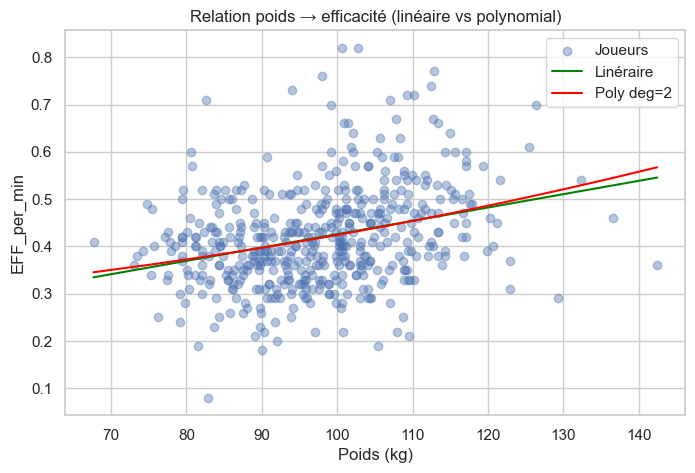

In [30]:
merged_NBA_height = merged_NBA[["weight_anthro", "EFF_per_min",'Player']].dropna()
merged_NBA_height = merged_NBA_height.drop_duplicates(subset=["Player"], keep="first")

#Préparer X (taille) et y (efficacité)
X = merged_NBA_height[["weight_anthro"]].values  # shape (n, 1)
y = merged_NBA_height["EFF_per_min"].values  # shape (n,)

#Modèle linéaire simple
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)
r2_lin = r2_score(y, y_pred_lin)
print("R² linéaire =", r2_lin)

#Modèle polynomial (par ex. degré 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)  # crée [height, height^2]

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)
print("R² polynomial (deg=2) =", r2_poly)

#Tracer les courbes
#On trie X pour avoir une courbe propre
X_sorted_idx = np.argsort(X[:, 0])
X_sorted = X[X_sorted_idx]
y_sorted_lin = y_pred_lin[X_sorted_idx]

X_sorted_poly = poly.transform(X_sorted)
y_sorted_poly = poly_reg.predict(X_sorted_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.4, label="Joueurs")
plt.plot(X_sorted, y_sorted_lin, color="green", label="Linéraire")
plt.plot(X_sorted, y_sorted_poly, color="red", label="Poly deg=2")
plt.xlabel("Poids (kg)")
plt.ylabel("EFF_per_min")
plt.legend()
plt.title("Relation poids → efficacité (linéaire vs polynomial)")
plt.show()


R² linéaire = 0.1217356067557458
R² polynomial (deg=2) = 0.16627999598666454


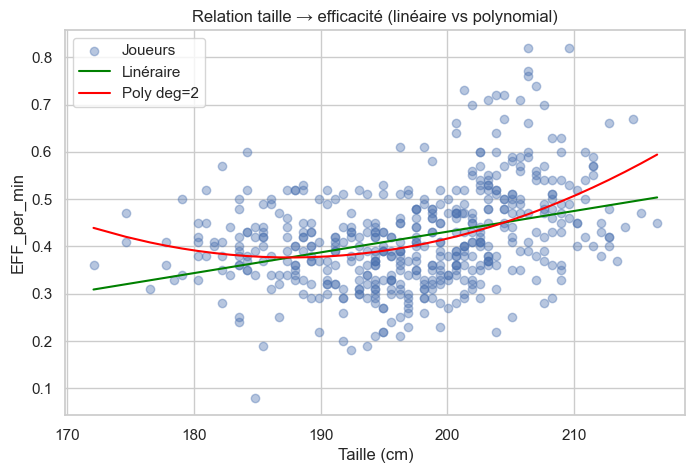

In [31]:
merged_NBA_height = merged_NBA[["height_anthro", "EFF_per_min",'Player']].dropna()
merged_NBA_height = merged_NBA_height.drop_duplicates(subset=["Player"], keep="first")

#Préparer X (taille) et y (efficacité)
X = merged_NBA_height[["height_anthro"]].values  # shape (n, 1)
y = merged_NBA_height["EFF_per_min"].values  # shape (n,)

#Modèle linéaire simple
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)
r2_lin = r2_score(y, y_pred_lin)
print("R² linéaire =", r2_lin)

#Modèle polynomial (par ex. degré 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)  # crée [height, height^2]

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)
print("R² polynomial (deg=2) =", r2_poly)

#Tracer les courbes
#On trie X pour avoir une courbe propre
X_sorted_idx = np.argsort(X[:, 0])
X_sorted = X[X_sorted_idx]
y_sorted_lin = y_pred_lin[X_sorted_idx]

X_sorted_poly = poly.transform(X_sorted)
y_sorted_poly = poly_reg.predict(X_sorted_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.4, label="Joueurs")
plt.plot(X_sorted, y_sorted_lin, color="green", label="Linéraire")
plt.plot(X_sorted, y_sorted_poly, color="red", label="Poly deg=2")
plt.xlabel("Taille (cm)")
plt.ylabel("EFF_per_min")
plt.legend()
plt.title("Relation taille → efficacité (linéaire vs polynomial)")
plt.show()

In [38]:
# Prepare data
df = merged_NBA.dropna(
    subset=["EFF_per_min", "height_anthro", "wingspan", "weight_anthro", "position"]
).copy()

df.loc[:, "position_simple"] = df["position"].str.split("/").str[0]

X = df[["height_anthro", "wingspan", "weight_anthro", "position_simple"]]
y = df["EFF_per_min"].values

print(f"Number of observations: {len(df)}")

# Preprocessor:
# - Polynomial terms for anthropometrics
# - One-hot encoding for position
preprocessor = ColumnTransformer([
    (
        "poly_features",
        PolynomialFeatures(degree=2, include_bias=False),
        ["height_anthro", "wingspan", "weight_anthro"]
    ),
    (
        "position_simple",
        OneHotEncoder(drop="first", sparse_output=False),
        ["position_simple"]
    )
])

# Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

# Fit model
model.fit(X, y)

# Model fit
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# ============================
# OLS output (interpretable)
# ============================

# Get feature names
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
feature_names_with_intercept = ["Intercept"] + list(feature_names)

# Statsmodels OLS
X_transformed = model.named_steps["preprocessor"].transform(X)
X_sm = sm.add_constant(X_transformed)
ols_model = sm.OLS(y, X_sm).fit()

# Extract results table
df_results = ols_model.summary2().tables[1].copy()
df_results.index = feature_names_with_intercept

df_results.columns = [
    "Coefficient",
    "Std. Error",
    "t-statistic",
    "P-value",
    "CI 2.5%",
    "CI 97.5%"
]

# Styling for Quarto
def style_pvalue(val):
    if val < 0.05:
        return "background-color: #d4edda; color: #155724; font-weight: bold"
    else:
        return "color: #721c24"

styled_table = (
    df_results.style
    .format("{:.4f}")
    .map(style_pvalue, subset=["P-value"])
    .background_gradient(cmap="Blues", subset=["Coefficient"])
    .set_caption(
        "📊 Polynomial Regression Results: Height, Wingspan, Weight, and Position"
    )
)

display(styled_table)


Number of observations: 3575


,Coefficient,Std. Error,t-statistic,P-value,CI 2.5%,CI 97.5%
Intercept,9.3201,1.4178,6.5734,0.0000,6.5402,12.1000
poly_features__height_anthro,-0.0272,0.0184,-1.4835,0.1380,-0.0632,0.0088
poly_features__wingspan,-0.0712,0.0119,-5.9792,0.0000,-0.0946,-0.0479
poly_features__weight_anthro,0.0144,0.0107,1.3467,0.1782,-0.0066,0.0354
poly_features__height_anthro^2,0.0000,0.0001,0.4138,0.6791,-0.0001,0.0002
poly_features__height_anthro wingspan,0.0000,0.0001,0.0509,0.9594,-0.0002,0.0002
poly_features__height_anthro weight_anthro,0.0001,0.0001,1.5504,0.1211,-0.0000,0.0003
poly_features__wingspan^2,0.0002,0.0001,3.4897,0.0005,0.0001,0.0003
poly_features__wingspan weight_anthro,-0.0002,0.0001,-2.3017,0.0214,-0.0003,-0.0000
poly_features__weight_anthro^2,-0.0000,0.0000,-0.7133,0.4757,-0.0001,0.0000
